## **RFM Score Calculation**

**Load Data**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file == 'online_retail_cleans.csv':
            print(os.path.join(root, file))

/content/drive/MyDrive/RFM_Customer_Segmentation/Data/online_retail_cleans.csv


In [6]:
df = pd.read_csv("/content/drive/MyDrive/RFM_Customer_Segmentation/Data/online_retail_cleans.csv")

### **Step 1: Set Reference Date**

In [7]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [8]:
# The date measure recency from
# taking last transaction date and add 1 day so that if anyone bought on last date will not show 0 recency
# reference_date = pd.Timestamp.today() - applicable for current date

reference_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
print(f"Reference Date: {reference_date.date()}")

Reference Date: 2011-12-10


### **Step 2: Calculate RFM Values**


In [9]:
rfm = df.groupby("CustomerID").agg(
    Recency = ("InvoiceDate", lambda x: (reference_date - x.max()).days),
    Frequency = ("InvoiceNo", "nunique"),
    Monetary = ("TotalPrice", "sum")
).reset_index()

rfm["Monetary"] = rfm["Monetary"].round(2)

print(f"RFM table: {rfm.shape[0]:,} customers")

RFM table: 4,338 customers


In [10]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


### **Step 3: Assign Scores 1 to 5**

In [11]:
# quantile cut

rfm["R_Score"] = pd.qcut(rfm["Recency"],
                         q=5, labels=[5, 4, 3, 2, 1]).astype(int)   # 5 Recently - 1 Gone Off

rfm["F_Score"] = pd.qcut(rfm["Frequency"].rank(method="first"),     # 1 One Time - 5 Frequently
                         q=5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["M_Score"] = pd.qcut(rfm["Monetary"],                           # 1 Less Amount - 5 High
                         q=5, labels=[1, 2, 3, 4, 5]).astype(int)

print(rfm[["CustomerID", "Recency", "Frequency", "Monetary", "R_Score", "F_Score", "M_Score"]].head())



   CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score
0       12346      326          1  77183.60        1        1        5
1       12347        2          7   4310.00        5        5        5
2       12348       75          4   1797.24        2        4        4
3       12349       19          1   1757.55        4        1        4
4       12350      310          1    334.40        1        1        2


### **Step 4: Combine Scores**

In [12]:
# Combing 3 scores into one string
# Example: R=5, F=5, M=5   --> "555" (Best Customer)
# Example: R=1, F=1, M=1   --> "111" (Worst Customer)

rfm["RFM_Score"] = (rfm["R_Score"].astype(str)+
                    rfm["F_Score"].astype(str)+
                    rfm["M_Score"].astype(str))

rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
0,12346,326,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,19,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


In [13]:
rfm[["CustomerID", "R_Score", "F_Score", "M_Score", "RFM_Score"]].head(10)

,CustomerID,R_Score,F_Score,M_Score,RFM_Score
0,12346,1,1,5,115
1,12347,5,5,5,555
2,12348,2,4,4,244
3,12349,4,1,4,414
4,12350,1,1,2,112
5,12352,3,5,5,355
6,12353,1,1,1,111
7,12354,1,1,4,114
8,12355,1,1,2,112
9,12356,4,3,5,435


### **Step 5: Visualize RFM**

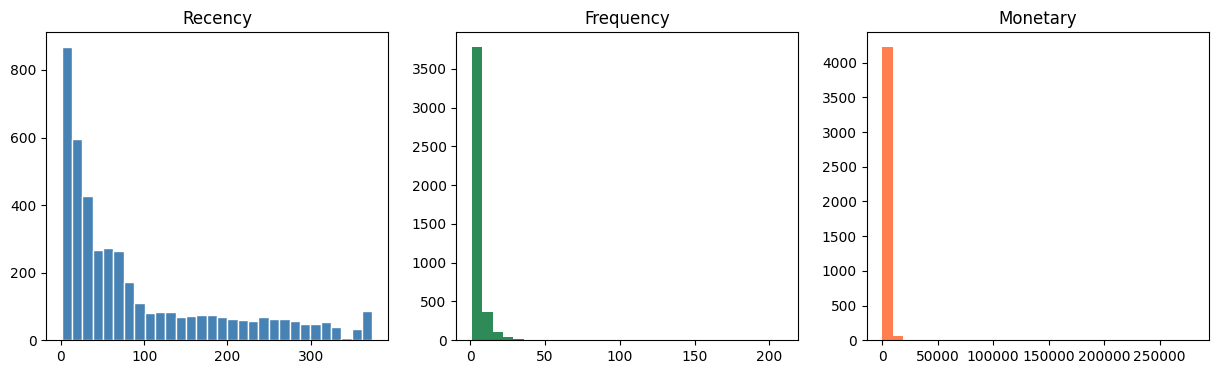

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1 - Recency
axes[0].hist(rfm["Recency"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Recency")

# Chart 2 - Frequency
axes[1].hist(rfm["Frequency"], bins=30, color="seagreen")
axes[1].set_title("Frequency")

# Chart 3 - Monetary
axes[2].hist(rfm["Monetary"], bins=30, color="coral")
axes[2].set_title("Monetary")

plt.savefig("/content/07_rfm_distribution.png", dpi=150)
plt.show()


> **Recency**

Good news! Customers are ACTIVE

Majority of people are recent buyers

Small group after 300+ days needs win-back campaign

> **Frequency**

MOST customers bought only 1-5 times only, not very
loyal customers

wherease a few customers buy very regularly customers (VIP)


> **Monetary**

MOST customers spend small amount between £0 to 20k
a few customers spend huge amounts!

In [15]:
# Save rfm table as csv file

rfm.to_csv('/content/rfm_scores.csv', index=False)
print("File saved successfully!")

File saved successfully!


In [16]:
from google.colab import files
files.download('/content/rfm_scores.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>